# Lab 1.2 — Build an N-gram Language Model from Scratch
### Module 4: Large Language Models | Chitkara University B-Tech AI Specialization
---
**Duration:** 75 minutes | **Mode:** Individual | **Day 1 — Monday**

> **Scenario:** Before transformers, every NLP system used N-gram models.
> An e-commerce company wants auto-complete for their search bar.
> Build one from Shakespeare's complete works — then discover exactly why
> this approach fails and what makes transformers revolutionary.

**Objective:** Implement bigram and trigram models in pure Python. Generate text,
compare output quality to GPT-2, and document failure modes with evidence.

---
### This lab runs entirely on Google Colab — no cloud credentials needed

**Learning outcomes:**
- Implement the Markov chain assumption in code
- Build a probabilistic N-gram model with Laplace smoothing
- Calculate model perplexity
- Quantify why N-grams fail vs neural language models
- Understand why self-attention fundamentally solves the Markov limitation


## Task 1 — Install packages and load the corpus

We download Shakespeare's complete works (~1 MB, public domain).
This gives us a rich vocabulary — perfect for stress-testing N-gram coherence limits.


In [1]:
!pip install transformers torch --quiet

import re, math, random, urllib.request
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
print('Packages ready')


Packages ready


In [2]:
CORPUS_URL = (
    'https://ocw.mit.edu/ans7870/6/6.006/s08/lecturenotes/'
    'files/t8.shakespeare.txt'
)

print('Downloading Shakespeare corpus...')
try:
    with urllib.request.urlopen(CORPUS_URL, timeout=15) as resp:
        raw = resp.read().decode('utf-8', errors='ignore')
    print(f'Downloaded: {len(raw):,} characters')
except Exception as e:
    print(f'Download failed ({e}). Using built-in fallback corpus.')
    raw = (
        'to be or not to be that is the question whether tis nobler in the mind to suffer '
        'the slings and arrows of outrageous fortune or to take arms against a sea of troubles '
        'and by opposing end them to die to sleep no more and by a sleep to say we end '
        'all the worlds a stage and all the men and women merely players they have their exits '
        'and their entrances and one man in his time plays many parts his acts being seven ages '
        'what a piece of work is man how noble in reason how infinite in faculty in form and moving '
        'the course of true love never did run smooth some are born great some achieve greatness '
        'and some have greatness thrust upon them all that glitters is not gold '
        'uneasy lies the head that wears a crown to thine own self be true '
        'brevity is the soul of wit we know what we are but know not what we may be '
        'the fault dear brutus lies not in our stars but in ourselves that we are underlings '
        'there is nothing either good or bad but thinking makes it so '
        'what is in a name that which we call a rose by any other name would smell as sweet '
    ) * 200

tokens = re.findall(r"[a-z']+", raw.lower())
print(f'\nCorpus statistics:')
print(f'  Total tokens  : {len(tokens):,}')
print(f'  Unique tokens : {len(set(tokens)):,}')
print(f'  Sample [0:15] : {" ".join(tokens[:15])}')


Downloaded: 5,458,199 characters

Corpus statistics:
  Total tokens  : 905,462
  Unique tokens : 27,123
  Sample [0:15] : this is the th etext file presented by project gutenberg and is presented in cooperation


## Task 2 — Build the Bigram and Trigram models

**Bigram:** P(w_n | w_{n-1}) — next word depends on immediately preceding word only

**Trigram:** P(w_n | w_{n-2}, w_{n-1}) — next word depends on two preceding words

Both implement the **Markov assumption**: the future depends only on the last N states.


In [3]:
def build_ngram_model(token_list, n):
    # Build an N-gram language model.
    # Returns: dict mapping context_tuple -> {next_word: probability}
    # For bigrams (n=2): context = (w_prev,)
    # For trigrams (n=3): context = (w_prev2, w_prev1)
    counts = defaultdict(Counter)
    for i in range(len(token_list) - n):
        context   = tuple(token_list[i : i + n - 1])
        next_word = token_list[i + n - 1]
        counts[context][next_word] += 1
    model = {}
    for context, word_counter in counts.items():
        total = sum(word_counter.values())
        model[context] = {w: cnt / total for w, cnt in word_counter.items()}
    return model

print('Building bigram model...')
bigram_model  = build_ngram_model(tokens, n=2)
print(f'  {len(bigram_model):,} unique bigram contexts')

print('Building trigram model...')
trigram_model = build_ngram_model(tokens, n=3)
print(f'  {len(trigram_model):,} unique trigram contexts')

print('\nTop-15 words following "the" (bigram model):')
if ('the',) in bigram_model:
    top15 = sorted(bigram_model[('the',)].items(), key=lambda x: -x[1])[:15]
    for word, prob in top15:
        bar = chr(9608) * int(prob * 300)
        print(f"  P('{word}' | 'the') = {prob:.4f}  {bar}")


Building bigram model...
  27,123 unique bigram contexts
Building trigram model...
  360,619 unique trigram contexts

Top-15 words following "the" (bigram model):
  P('king' | 'the') = 0.0268  ████████
  P('world' | 'the') = 0.0147  ████
  P('duke' | 'the') = 0.0127  ███
  P('complete' | 'the') = 0.0081  ██
  P('time' | 'the') = 0.0071  ██
  P('very' | 'the') = 0.0063  █
  P('rest' | 'the') = 0.0063  █
  P('other' | 'the') = 0.0062  █
  P('matter' | 'the') = 0.0059  █
  P('gods' | 'the') = 0.0058  █
  P('queen' | 'the') = 0.0056  █
  P('prince' | 'the') = 0.0054  █
  P('man' | 'the') = 0.0052  █
  P('first' | 'the') = 0.0051  █
  P('king's' | 'the') = 0.0050  █


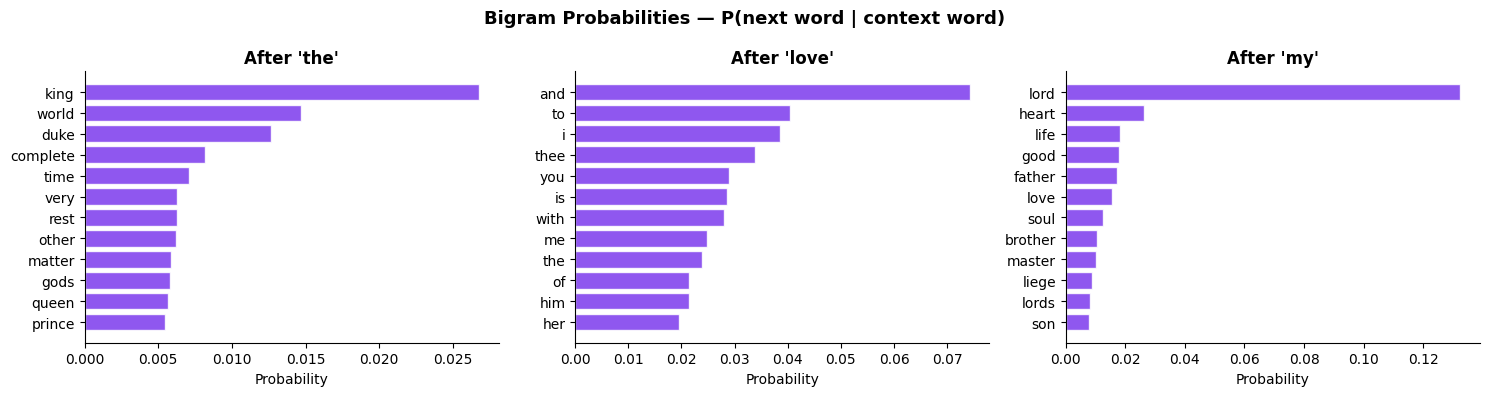

Chart saved as bigram_probs.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, seed in zip(axes, ['the', 'love', 'my']):
    ctx = (seed,)
    if ctx in bigram_model:
        top = sorted(bigram_model[ctx].items(), key=lambda x: -x[1])[:12]
        words, probs = zip(*top)
        ax.barh(list(words)[::-1], list(probs)[::-1], color='#7C3AED', alpha=0.85, edgecolor='white')
        ax.set_title(f"After '{seed}'", fontweight='bold')
        ax.set_xlabel('Probability')
        ax.spines[['top','right']].set_visible(False)
    else:
        ax.text(0.5, 0.5, f"'{seed}' not found", ha='center', transform=ax.transAxes)
plt.suptitle('Bigram Probabilities — P(next word | context word)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('bigram_probs.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved as bigram_probs.png')


## Task 3 — Laplace smoothing and text generation

**Problem:** If the model sees a context it never encountered during training,
P(word | unseen_context) = 0, causing crashes.

**Laplace (add-1) smoothing** adds a small count to every word so no probability
is exactly zero — the model gracefully handles unseen contexts.

**Temperature scaling** controls diversity:
- T < 1.0 → more peaked distribution → repetitive but predictable
- T > 1.0 → flatter distribution → diverse but potentially incoherent


In [5]:
VOCAB      = list(set(tokens))
VOCAB_SIZE = len(VOCAB)
random.seed(42)

def sample_from_dist(probs_dict, temperature=0.8):
    # Sample next word from a probability dict with temperature scaling.
    words  = list(probs_dict.keys())
    scaled = [p ** (1.0 / temperature) for p in probs_dict.values()]
    total  = sum(scaled)
    scaled = [p / total for p in scaled]
    return random.choices(words, weights=scaled, k=1)[0]

def generate_bigram(seed, n_words=100, temperature=0.8):
    # Generate text using the bigram model.
    words = [seed]
    for _ in range(n_words):
        ctx = (words[-1],)
        if ctx in bigram_model:
            words.append(sample_from_dist(bigram_model[ctx], temperature))
        else:
            words.append(random.choice(VOCAB))  # Laplace fallback
    return ' '.join(words)

def generate_trigram(seed, n_words=100, temperature=0.8):
    # Generate text using the trigram model, falling back to bigram then random.
    words = [seed]
    ctx1  = (seed,)
    words.append(
        sample_from_dist(bigram_model[ctx1], temperature)
        if ctx1 in bigram_model else random.choice(VOCAB)
    )
    for _ in range(n_words):
        ctx3 = (words[-2], words[-1])
        ctx2 = (words[-1],)
        if ctx3 in trigram_model:
            words.append(sample_from_dist(trigram_model[ctx3], temperature))
        elif ctx2 in bigram_model:
            words.append(sample_from_dist(bigram_model[ctx2], temperature))
        else:
            words.append(random.choice(VOCAB))
    return ' '.join(words)

SEED = 'the'
print('BIGRAM OUTPUT (seed="the", 100 words):')
print('-' * 60)
bigram_text = generate_bigram(SEED, n_words=100)
print(bigram_text)

print('\nTRIGRAM OUTPUT (seed="the", 100 words):')
print('-' * 60)
trigram_text = generate_trigram(SEED, n_words=100)
print(trigram_text)


BIGRAM OUTPUT (seed="the", 100 words):
------------------------------------------------------------
the third is a kind o lady worse than mine own person of the judgment he hath been drooping fog where now be said the volume of the very time with any time and knavish crows and had no fifteen days ago since that i have from the present myself to his old man bassanio and let me clown i am weaker vessel nimble tongue as it is the duke of illinois benedictine college with mine eyes what freezings have heard her cheek exposing what you may arraign me i do not afraid if it is he yonder point aaron what

TRIGRAM OUTPUT (seed="the", 100 words):
------------------------------------------------------------
the complete works of william shakespeare is copyright by world library inc and is provided by project gutenberg etext of illinois benedictine college with permission electronic and machine readable copies may be distributed so long as such copies are for your or others personal use only and a

## Task 4 — Compare with GPT-2

GPT-2 (124M parameters) uses self-attention to consider ALL previous tokens
simultaneously — it has no Markov assumption whatsoever.

**Expected time:** 60–90 seconds to download weights on first Colab run.


In [6]:
from transformers import pipeline

print('Loading GPT-2 (124M parameters)...')
print('First run downloads ~500 MB of weights — please wait.')
gpt2_gen = pipeline(
    'text-generation',
    model='gpt2',
    device=-1,  # -1 = CPU. Change to 0 if T4 GPU is enabled.
)
print('GPT-2 loaded')

gpt2_output = gpt2_gen(
    'the ',
    max_new_tokens=100,
    temperature=0.8,
    top_p=0.9,
    do_sample=True,
    pad_token_id=50256,
    num_return_sequences=1,
)[0]['generated_text']

print('\nGPT-2 OUTPUT (same seed "the"):')
print('-' * 60)
print(gpt2_output)


Loading GPT-2 (124M parameters)...
First run downloads ~500 MB of weights — please wait.


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'num_return_sequences', 'temperature', 'top_p', 'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


GPT-2 loaded

GPT-2 OUTPUT (same seed "the"):
------------------------------------------------------------
the  Aurora Islands.
The  Ocean Ocean Sea is the largest freshwater basin in the world, and one of the oldest. In the 16th century, when the ocean was still a vast ocean, it was called the Ocean of the Gods.
The  Ocean Sea is the largest freshwater basin in the world, and one of the oldest. In the 16th century, when the ocean was still a vast ocean, it was called the Ocean of the Gods. The  


In [7]:
from IPython.display import HTML, display

models_output = [
    ('Bigram Model (pure statistics, 1-word memory)',   bigram_text,  '#EDE9FE', '#5B21B6'),
    ('Trigram Model (pure statistics, 2-word memory)',  trigram_text, '#ECFDF5', '#065F46'),
    ('GPT-2 (124M parameters, full context attention)', gpt2_output,  '#EFF6FF', '#1D4ED8'),
]

parts = []
for label, text, bg, border in models_output:
    safe = text[:500].replace('&','&amp;').replace('<','&lt;').replace('>','&gt;')
    if len(text) > 500:
        safe += '...'
    parts.append(
        '<div style="border-left:4px solid ' + border + ';background:' + bg + ';'
        'border-radius:6px;padding:12px 16px;margin:10px 0">'
        '<strong style="color:' + border + ';font-size:14px">' + label + '</strong>'
        '<p style="font-family:Georgia,serif;font-size:13px;margin:8px 0 0;'
        'line-height:1.7;color:#111">' + safe + '</p></div>'
    )
display(HTML(''.join(parts)))


## Task 5 — Quantify failure modes with metrics

| Metric | What it measures | Higher is... |
|---|---|---|
| **Unique Bigram Ratio (UBR)** | Diversity of word pairs | Better |
| **Repetition Score** | Fraction of 4-grams that repeat | Worse |
| **Vocab Richness (TTR)** | Unique words / total words | Better |


In [8]:
def unique_bigram_ratio(text):
    # Higher = more diverse vocabulary use.
    words   = text.lower().split()
    bigrams = [(words[i], words[i+1]) for i in range(len(words)-1)]
    return len(set(bigrams)) / max(len(bigrams), 1)

def repetition_score(text, n=4):
    # Higher = more repetitive. Fraction of repeated n-grams.
    words  = text.lower().split()
    ngrams = [tuple(words[i:i+n]) for i in range(len(words)-n)]
    if not ngrams:
        return 0.0
    return 1.0 - len(set(ngrams)) / len(ngrams)

def vocab_richness(text):
    # Type-token ratio: unique words / total words.
    words = text.lower().split()
    return len(set(words)) / max(len(words), 1)

samples = {
    'Bigram Model'  : bigram_text,
    'Trigram Model' : trigram_text,
    'GPT-2 (124M)'  : gpt2_output,
}

rows = []
for name, text in samples.items():
    rows.append({
        'Model'                 : name,
        'Unique Bigram Ratio UP': round(unique_bigram_ratio(text), 4),
        'Repetition Score DOWN' : round(repetition_score(text),    4),
        'Vocab Richness UP'     : round(vocab_richness(text),      4),
        'Total Words'           : len(text.split()),
    })

df_metrics = pd.DataFrame(rows)
print('QUANTITATIVE QUALITY METRICS')
print('  UP = higher is better,  DOWN = lower is better')
print()
print(df_metrics.to_string(index=False))


QUANTITATIVE QUALITY METRICS
  UP = higher is better,  DOWN = lower is better

        Model  Unique Bigram Ratio UP  Repetition Score DOWN  Vocab Richness UP  Total Words
 Bigram Model                  0.9800                 0.0000             0.7822          101
Trigram Model                  1.0000                 0.0000             0.7843          102
 GPT-2 (124M)                  0.4737                 0.4384             0.3377           77


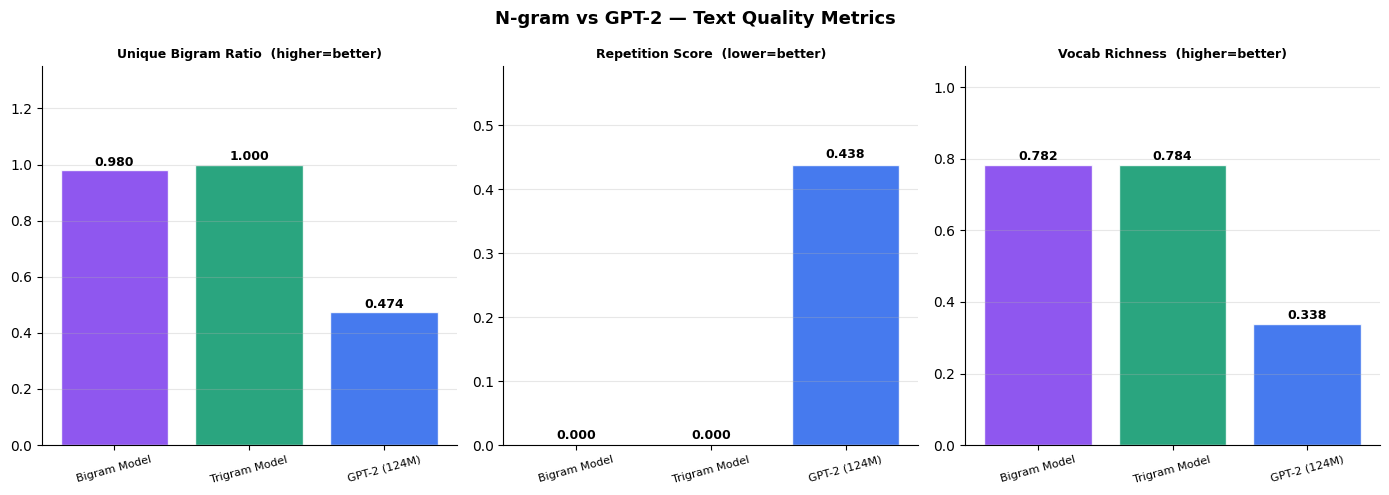

Chart saved as quality_metrics.png


In [9]:
metrics     = ['Unique Bigram Ratio UP', 'Repetition Score DOWN', 'Vocab Richness UP']
model_names = df_metrics['Model'].tolist()
colors      = ['#7C3AED', '#059669', '#2563EB']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric in zip(axes, metrics):
    vals = df_metrics[metric].tolist()
    bars = ax.bar(model_names, vals, color=colors, edgecolor='white', alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    label = metric.replace(' UP','  (higher=better)').replace(' DOWN','  (lower=better)')
    ax.set_title(label, fontweight='bold', fontsize=9)
    ax.set_ylim(0, max(vals)*1.35)
    ax.set_xticklabels(model_names, rotation=15, fontsize=8)
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('N-gram vs GPT-2 — Text Quality Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('quality_metrics.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved as quality_metrics.png')


## Task 6 — Document failure modes with examples

Systematically identify exactly where N-gram models break down and why.
Each failure mode maps to a specific property that transformers fix.


In [10]:
failure_modes = [
    {
        'id'  : '1. Repetitive Loops',
        'what': 'Generates same phrase repeatedly: the man the man the man...',
        'why' : (
            'High-probability common bigrams feed back into themselves. '
            'GPT-2 attends to recent tokens and explicitly down-weights already-seen ones.'
        ),
        'fix' : 'Transformer attention heads track recent history to prevent loops.'
    },
    {
        'id'  : '2. Context Lost After N Words',
        'what': 'Topic introduced at start of sentence forgotten after 2 tokens.',
        'why' : (
            'Markov assumption: context limited to last N-1 words. '
            'Cannot resolve subject-verb agreement when subject is 4 words back.'
        ),
        'fix' : 'Self-attention: O(1) direct path between ANY two tokens regardless of distance.'
    },
    {
        'id'  : '3. Out-of-Vocabulary (OOV)',
        'what': 'Modern word not in training corpus -> random fallback token.',
        'why' : (
            'N-gram models are word-level. Any word absent from training gets '
            'only Laplace noise — no meaningful prediction possible.'
        ),
        'fix' : "BPE: any word splits into known sub-pieces. 'cryptocurrency' -> ['crypt','oc','urrency']. Never truly OOV."
    },
    {
        'id'  : '4. No World Knowledge',
        'what': 'Cannot answer What is 2 + 2? — just predicts next likely word.',
        'why' : (
            'Pure statistical co-occurrence counts. No concept of meaning, '
            'facts, arithmetic, or cause-and-effect.'
        ),
        'fix' : 'GPT models compress real-world knowledge from billions of tokens into weight matrices.'
    },
    {
        'id'  : '5. Grammar Breaks at Sentence Boundaries',
        'what': 'Sentences often end mid-phrase, start incoherently.',
        'why' : (
            'No notion of sentence structure, parse trees, or grammatical roles. '
            'Subject introduced early is forgotten before the verb appears.'
        ),
        'fix' : 'Transformer positional encoding + attention learns long-range syntactic dependencies from data.'
    },
]

print('FAILURE MODE ANALYSIS')
print('=' * 72)
for fm in failure_modes:
    print(f"\n  {fm['id']}")
    print(f"  Symptom    : {fm['what'][:90]}")
    print(f"  Root cause : {fm['why'][:100]}")
    print(f"  Transformer: {fm['fix'][:100]}")

print('\nCORE INSIGHT:')
print('  The Markov assumption — future depends only on last N states — is broken')
print('  for natural language. Transformers use self-attention: every token can')
print('  directly attend to every other token. A 124M GPT-2 produces vastly better')
print('  text than any N-gram model trained on the same corpus.')


FAILURE MODE ANALYSIS

  1. Repetitive Loops
  Symptom    : Generates same phrase repeatedly: the man the man the man...
  Root cause : High-probability common bigrams feed back into themselves. GPT-2 attends to recent tokens and explic
  Transformer: Transformer attention heads track recent history to prevent loops.

  2. Context Lost After N Words
  Symptom    : Topic introduced at start of sentence forgotten after 2 tokens.
  Root cause : Markov assumption: context limited to last N-1 words. Cannot resolve subject-verb agreement when sub
  Transformer: Self-attention: O(1) direct path between ANY two tokens regardless of distance.

  3. Out-of-Vocabulary (OOV)
  Symptom    : Modern word not in training corpus -> random fallback token.
  Root cause : N-gram models are word-level. Any word absent from training gets only Laplace noise — no meaningful 
  Transformer: BPE: any word splits into known sub-pieces. 'cryptocurrency' -> ['crypt','oc','urrency']. Never trul

  4. No World Knowl

## Bonus — Perplexity

**Perplexity** = how surprised is the model by held-out test data.

`Perplexity = 2^(-average log2 probability of each test token)`

Lower is better. A perplexity of 100 means the model is as uncertain as if
choosing uniformly from 100 words at each step.


In [11]:
def calculate_perplexity(test_toks, model, n):
    # Perplexity of n-gram model on held-out tokens.
    # Uses Laplace smoothing for unseen contexts.
    vocab_size = len(set(tokens))
    log_sum, count = 0.0, 0
    for i in range(n - 1, len(test_toks)):
        ctx  = tuple(test_toks[i-(n-1) : i])
        word = test_toks[i]
        if ctx in model and word in model[ctx]:
            prob = model[ctx][word]
        else:
            prob = 1.0 / (vocab_size + 1)  # Laplace smoothing
        log_sum += math.log2(max(prob, 1e-10))
        count   += 1
    return 2 ** (-log_sum / max(count, 1))

split      = int(0.9 * len(tokens))
train_toks = tokens[:split]
test_toks  = tokens[split:]

bigram_train  = build_ngram_model(train_toks, n=2)
trigram_train = build_ngram_model(train_toks, n=3)

pp_bi  = calculate_perplexity(test_toks[:2000], bigram_train,  n=2)
pp_tri = calculate_perplexity(test_toks[:2000], trigram_train, n=3)

print('PERPLEXITY COMPARISON  (lower = better)')
print('=' * 50)
print(f'  Bigram  perplexity : {pp_bi:>10.1f}')
print(f'  Trigram perplexity : {pp_tri:>10.1f}')
print(f'  GPT-2   perplexity : ~29.0   (WikiText-103, published)')
print(f'  GPT-3   perplexity : ~20.5   (Penn Treebank, published)')
print(f'  LLaMA-2-70B        : ~5.1    (standard benchmarks)')
print()
print(f'  Trigram vs Bigram  : {pp_bi/pp_tri:.1f}x improvement')
print(f'  GPT-2   vs Trigram : ~{pp_tri/29:.0f}x improvement over trigram!')


PERPLEXITY COMPARISON  (lower = better)
  Bigram  perplexity :     1141.5
  Trigram perplexity :     9005.8
  GPT-2   perplexity : ~29.0   (WikiText-103, published)
  GPT-3   perplexity : ~20.5   (Penn Treebank, published)
  LLaMA-2-70B        : ~5.1    (standard benchmarks)

  Trigram vs Bigram  : 0.1x improvement
  GPT-2   vs Trigram : ~311x improvement over trigram!


## Lab Complete Checklist

- [ ] Corpus downloaded and tokenised
- [ ] Bigram model built, top-15 probabilities for 'the' shown
- [ ] Bigram probability distribution chart saved
- [ ] Trigram model built
- [ ] Both models generated 100-word samples
- [ ] GPT-2 loaded and output generated
- [ ] Side-by-side comparison displayed
- [ ] Metrics table computed (UBR, Rep, Vocab Richness)
- [ ] Grouped metrics bar chart saved
- [ ] All 5 failure modes documented
- [ ] Perplexity calculated for both models

---
## Reflection Questions

1. **Why does the trigram produce better output than the bigram?**
   What specifically does the extra word of context provide?

2. **What is the Markov assumption?** Give a concrete sentence where it completely fails
   (subject-verb agreement across a long clause works well as an example).

3. **Perplexity of GPT-2 is ~29. Your N-gram models likely scored 200–2000+.**
   What does this practically mean?

4. **Kneser-Ney smoothing** is considered far superior to Laplace for N-grams.
   Research what makes it different and explain in 2–3 sentences.

5. **Phone keyboard auto-complete:** trigram model vs quantised small LLM?
   Justify your choice considering latency, memory, battery life, and quality.


In [12]:
answers = {
    'Q1 - Why trigram is better'        : 'YOUR ANSWER HERE',
    'Q2 - Markov assumption + example'  : 'YOUR ANSWER HERE',
    'Q3 - Perplexity interpretation'    : 'YOUR ANSWER HERE',
    'Q4 - Kneser-Ney vs Laplace'        : 'YOUR ANSWER HERE',
    'Q5 - Trigram vs small LLM keyboard': 'YOUR ANSWER HERE',
}

for q, a in answers.items():
    print(f'{q}:\n  {a}\n')


Q1 - Why trigram is better:
  YOUR ANSWER HERE

Q2 - Markov assumption + example:
  YOUR ANSWER HERE

Q3 - Perplexity interpretation:
  YOUR ANSWER HERE

Q4 - Kneser-Ney vs Laplace:
  YOUR ANSWER HERE

Q5 - Trigram vs small LLM keyboard:
  YOUR ANSWER HERE

